# Streamlit

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from lightgbm import LGBMRegressor

In [15]:
base_dir = r'C:\FBr\Weiterbildung\Project\GitHub\sep24_cds_int_us-welding'

ft_param_path = os.path.join(base_dir, 'ft_files', '03_feat_parameters.ft')
ft_modes_path = os.path.join(base_dir, 'ft_files', '03_coll_modes.ft')
ft_nodes_path = os.path.join(base_dir, 'ft_files', '03_coll_nodes.ft')
ft_defs_path = os.path.join(base_dir, 'ft_files', '03_coll_defs.ft')

df_params = pd.read_feather (ft_param_path)
df_modes = pd.read_feather (ft_modes_path)
df_nodes = pd.read_feather (ft_nodes_path)
df_defs = pd.read_feather (ft_defs_path)

In [24]:
# Select the relevant columns of df_params only
lst_param = df_params.columns.tolist()
lst_param_geom = lst_param[1:24]
lst_param_sel = [lst_param[0]] + lst_param_geom + lst_param[24:26] + lst_param[29:32] + lst_param[57:61] + lst_param[137:139]
df_params = df_params[lst_param_sel]

In [ ]:
# Load models

Exploration and visualization of the data

Data exploration

In [25]:
df_params.head(100)

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,cut_x_end,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,mode_no_long,freq_long,long_disp_mean,long_disp_max,long_disp_min
0,1001,175.06,121.95,240.31,4,75.993,43.235,2,78.219,59.508,...,97.910,0.88177,25.293,66.060,1.99450,77,19217.965,0.280277,0.398564,0.140101
1,1002,173.45,122.77,238.13,4,81.168,45.859,2,78.924,57.208,...,79.356,4.85900,26.997,56.481,4.80300,79,19386.656,0.293080,0.416231,0.135763
2,1003,175.85,116.71,238.10,4,77.532,45.260,2,80.099,49.215,...,83.599,1.21780,22.264,51.204,0.81847,79,20087.459,0.321250,0.430937,0.264546
3,1004,173.51,116.37,238.30,4,82.428,51.007,2,74.757,50.840,...,63.529,4.16500,37.379,58.304,1.02820,80,20209.177,0.318636,0.435829,0.181880
4,1005,175.60,118.72,241.04,4,76.576,45.981,2,78.773,64.702,...,89.119,0.64304,27.381,51.502,0.74029,79,19813.899,0.309465,0.376213,0.255784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,175.13,118.17,238.38,4,79.060,51.158,2,80.872,57.562,...,84.607,4.98390,35.352,63.466,3.65550,80,20233.910,0.302259,0.460016,0.124052
96,1097,174.32,119.14,240.99,4,74.494,46.789,2,77.106,65.917,...,85.135,4.40280,37.108,55.619,1.29660,79,19967.854,0.296686,0.395643,0.191501
97,1098,174.28,123.09,238.57,4,77.508,46.936,2,82.872,53.867,...,67.359,4.49600,33.461,67.169,0.78040,79,19239.180,0.303979,0.366455,0.236051
98,1099,174.76,115.05,240.04,4,79.014,51.881,2,76.445,57.222,...,67.626,2.56870,36.136,54.001,1.19860,80,20341.104,0.308363,0.440703,0.098320


In [29]:
df_modes.head(152)

,dp_no,mode_no,freq,rel_dev,mean_in_disp,mean_out_disp,mode_gain,mode_mac
0,1000,25,11705.549,120.61732,-0.121,0.002,0.01985,0.076401
1,1000,26,11987.927,412.69239,-0.009,0.002,0.26013,0.000220
2,1000,27,12187.892,474.99649,0.000,0.001,2.26471,0.000035
3,1000,28,12318.561,11.80434,-0.065,-0.046,0.71102,0.009971
4,1000,29,12598.709,847.60025,0.001,0.000,0.92230,0.000006
...,...,...,...,...,...,...,...,...
147,1001,96,23405.312,279.90924,-0.000,0.004,69.26305,0.000073
148,1001,97,23675.613,347.79353,-0.018,-0.003,0.17265,0.000213
149,1001,98,23754.253,203.12398,-0.046,-0.002,0.05382,0.010735
150,1001,99,23860.316,161.46847,-0.004,-0.007,1.96045,0.000435


In [38]:
df_nodes.head(495)

,dp_no,node_no,x_coord,y_coord,z_coord
0,1000,1,-120.01500,0.0,-76.720000
1,1000,11,-120.01500,0.0,76.720000
2,1000,12,-120.01500,0.0,57.540000
3,1000,13,-120.01500,0.0,38.360000
4,1000,14,-120.01500,0.0,19.180000
...,...,...,...,...,...
490,1000,10210,-37.47987,0.0,69.283814
491,1001,1,-120.15500,0.0,-82.064300
492,1001,12,-120.15500,0.0,82.064300
493,1001,13,-120.15500,0.0,63.827789


In [39]:
df_defs.head(495)

,dp_no,node_no,mode25,mode26,mode27,mode28,mode29,mode30,mode31,mode32,...,mode91,mode92,mode93,mode94,mode95,mode96,mode97,mode98,mode99,mode100
0,1000,1,0.134142,0.216114,0.193092,-0.297784,0.046671,0.101679,-0.038922,0.039048,...,-0.290045,-0.330238,-0.418750,-0.396922,0.167523,-0.294506,0.305611,0.242859,-0.131780,-0.102837
1,1000,11,0.133235,-0.224205,0.177632,-0.296075,-0.053283,-0.110080,-0.023488,0.037248,...,-0.295936,-0.325200,-0.413388,-0.399802,0.185901,0.240496,0.349572,0.235923,0.139851,-0.066484
2,1000,12,0.067980,-0.244073,0.067255,-0.170133,0.017068,-0.028849,-0.032300,-0.002932,...,0.002639,-0.088270,-0.416453,-0.475318,0.080366,0.157874,-0.031110,0.535567,-0.200790,-0.409373
3,1000,13,-0.013566,-0.263616,-0.039998,-0.027363,0.124321,0.080527,-0.013113,-0.022632,...,0.169028,0.109970,0.005401,-0.042836,-0.001065,0.016996,-0.298478,0.215014,-0.454417,-0.438804
4,1000,14,-0.091604,-0.232150,-0.146628,0.080373,0.196288,0.157715,-0.005128,-0.053346,...,0.000723,0.090866,0.728555,0.792384,-0.042708,-0.064504,-0.377651,-0.633504,-0.411714,-0.202440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,1000,10210,-0.052602,0.374043,-0.034945,-0.203935,0.034757,0.118696,0.099449,-0.026174,...,0.038006,0.188911,0.088049,0.076781,-0.079727,-0.015161,-0.123634,0.100086,-0.053007,-0.067978
491,1001,1,-0.065911,0.178204,0.259102,0.250183,0.010527,-0.210316,0.033066,0.096892,...,0.080021,0.337979,0.073709,-0.335636,-0.567224,-0.027954,0.000626,-0.270824,-0.221469,-0.122088
492,1001,12,0.066035,0.176695,0.364835,0.022659,0.016073,-0.197222,-0.029031,-0.090751,...,0.095241,-0.312241,-0.066837,0.317554,0.573101,0.024126,-0.036901,-0.242830,-0.242739,0.146983
493,1001,13,0.060209,0.157794,0.365830,-0.024725,0.045843,-0.082772,-0.035403,0.032874,...,0.106189,0.061989,-0.018170,0.349185,0.097354,0.380041,-0.043881,-0.243067,-0.416460,-0.066137


Example of DP 1001

In [51]:
dp = 1001

In [53]:
df_params.loc[df_params['dp_no'] == dp]
# Geometrical parameters
# Identified longitudinal mode for this design point: 77

,dp_no,dim_x,dim_y,dim_z,nb_slots_x,slot_x_length,slot_x_distance,nb_slots_z,slot_z_length,slot_z_distance,...,cut_x_end,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,mode_no_long,freq_long,long_disp_mean,long_disp_max,long_disp_min
0,1001,175.06,121.95,240.31,4,75.993,43.235,2,78.219,59.508,...,97.91,0.88177,25.293,66.06,1.9945,77,19217.965,0.280277,0.398564,0.140101


In [ ]:
# List of modes around 77
lst_modes = range(id_long-4, id_long+4)
df_params.loc[(df_params['dp_no'] == id_long) & (df_params['dp_no'].isin(lst_modes))]

# Look at frequencies and MAC

In [ ]:


# Display displacement of the output surface
plot_displacement(df_modes, df_nodes, df_defs, dp, id_long, True);

Data visualization

C:\Users\fbrouet\AppData\Local\Temp\ipykernel_25100\2770378148.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df_params[lst_param_geom], labels=lst_param_geom)


[]

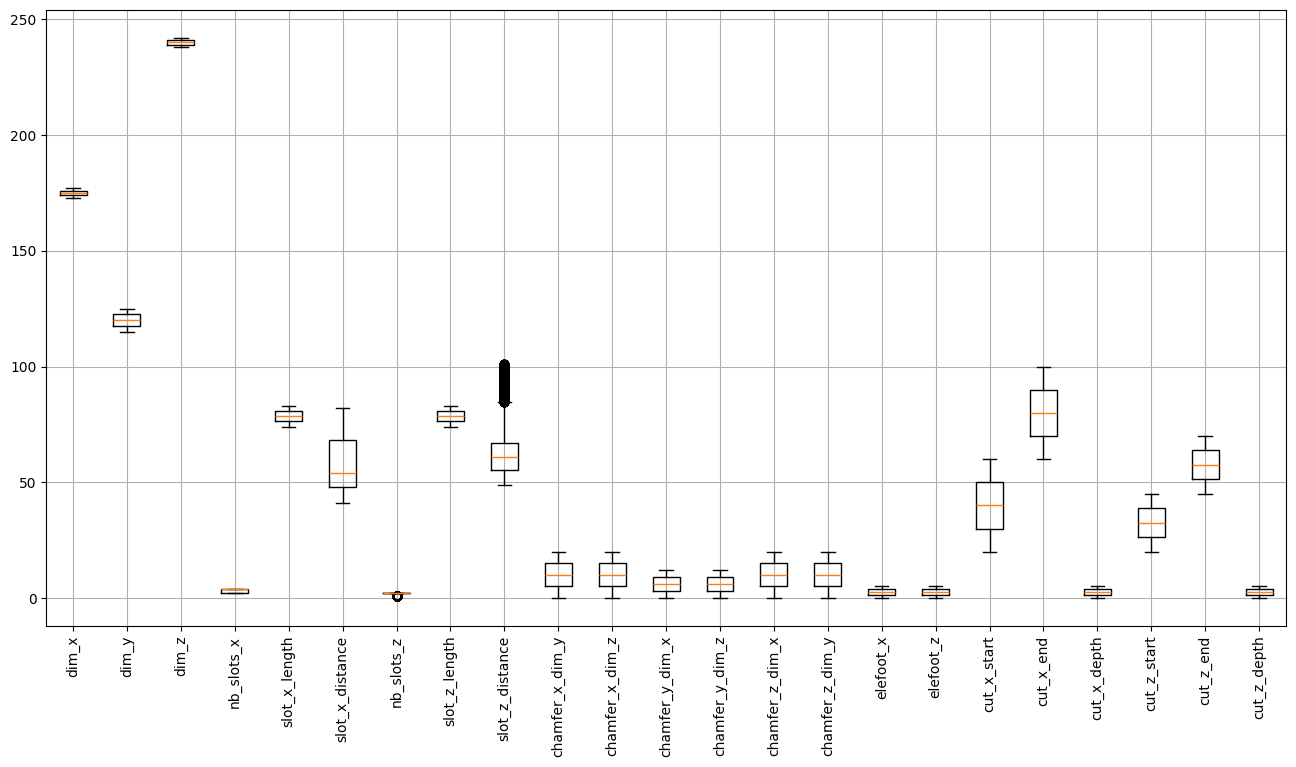

In [26]:
fig, ax = plt.subplots(figsize=(16, 8))
plt.boxplot(df_params[lst_param_geom], labels=lst_param_geom)
plt.xticks(rotation=90)
plt.grid(True)
plt.plot()